# Etablish Baseline

### 1. Goal And Setup

Question: How much of UdonPred's apparent performance is above trivial sequence signal,
random-label training, and annotation noise?


In [18]:
# !pip install -r ../requirements.txt

from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"


### 2. Load  or Calculate Raw UdonPred 7x7 Matrix

In [19]:
# check if matrix already exists
matrix_csv = RESULTS / "udonpred_matrix" / "matrix.csv"
if not matrix_csv.exists():
    print("Running UdonPred matrix computation...")
    # !python ../scripts/run_udonpred_matrix.py --output_dir ../results/udonpred_matrix --device cpu
else:
    print("UdonPred matrix already exists, skipping computation.")

udon_matrix = pd.read_csv(RESULTS / "udonpred_matrix" / "matrix.csv")
udon_matrix

UdonPred matrix already exists, skipping computation.


,train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot\n(AP),disprot\n(AUROC)
0,trizod,0.507853,0.707732,0.257050,-0.005696,0.412662,0.718810,0.898505,0.929508
1,chezod,0.486243,0.691124,0.234814,-0.038872,0.326703,0.713062,0.889928,0.925150
2,softdis,0.470177,0.536943,0.499879,0.149685,0.596582,0.784314,0.872120,0.917547
3,pdbflex,0.286765,0.285551,0.291659,0.395383,0.349231,0.519823,0.519235,0.737309
4,atlas,0.399847,0.594801,0.309795,0.055761,0.708063,0.718784,0.870035,0.920100
5,plddt,0.422638,0.624582,0.283637,0.103985,0.512167,0.838924,0.874971,0.927180
6,disprot,0.364121,0.663372,0.254746,0.098709,0.623971,0.774079,0.935162,0.958705


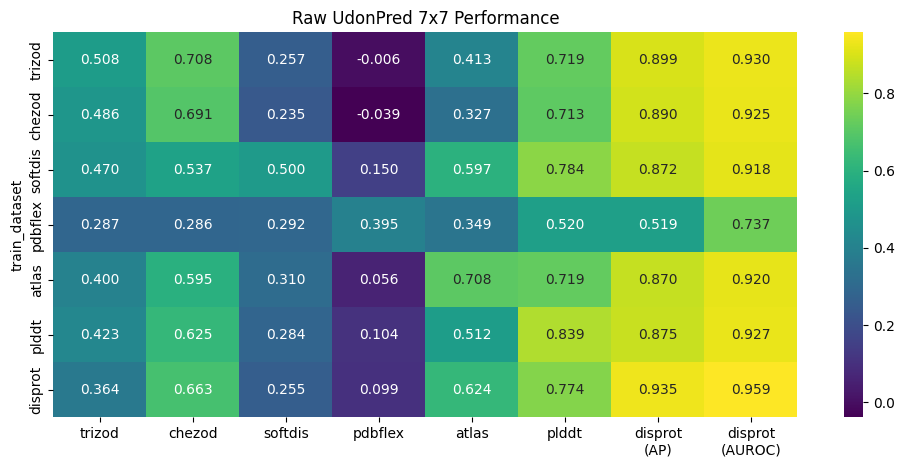

In [20]:
metric_cols = [
    "trizod", "chezod", "softdis", "pdbflex",
    "atlas", "plddt", "disprot\n(AP)", "disprot\n(AUROC)"
]
plt.figure(figsize=(12, 5))
sns.heatmap(
    udon_matrix.set_index("train_dataset")[metric_cols],
    annot=True,
    fmt=".3f",
    cmap="viridis",
)
plt.title("Raw UdonPred 7x7 Performance")
plt.show()


### 3. Create Simple Baseline

Amino acid composition logistic regression estimates how much signal is recoverable from global sequence composition.
Coil propensity estimates how much local secondary-structure-like signal explains disorder labels.

The idea is to test the model in the same way as UdonPred to obtain a comparable 7x7 matrix.

In [21]:
if (RESULTS / "simple_baselines" / "matrix.csv").exists():
    print("Baseline matrix already exists, skipping computation.")
else:
    print("Running simple baselines matrix computation...")
    # !python ../scripts/run_simple_baselines.py

baseline_matrix = pd.read_csv(RESULTS / "simple_baselines" / "matrix.csv")
baseline_matrix

Baseline matrix already exists, skipping computation.


,baseline,train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot\n(AP),disprot\n(AUROC)
0,aa_composition_logreg,trizod_composition,0.195902,0.507563,0.044220,-0.005160,0.209722,0.311141,0.625382,0.753995
1,aa_composition_logreg,chezod_composition,0.196422,0.530384,0.041916,-0.022796,0.188351,0.313210,0.639465,0.747486
2,aa_composition_logreg,softdis_composition,0.072778,0.220479,0.063046,0.148319,0.304284,0.204617,0.458099,0.639652
3,aa_composition_logreg,pdbflex_composition,-0.067947,-0.200473,0.016496,0.196044,0.067581,-0.139738,0.291242,0.396673
4,aa_composition_logreg,atlas_composition,0.047229,0.303521,0.053872,0.102446,0.255967,0.205078,0.487039,0.627038
5,aa_composition_logreg,plddt_composition,0.177596,0.484770,0.052803,0.020923,0.259729,0.328734,0.597429,0.734311
6,aa_composition_logreg,disprot_composition,0.165639,0.536459,0.037801,-0.017021,0.104685,0.323943,0.621937,0.735986
7,coil_propensity,none_coil,0.273706,0.228599,0.200564,0.062577,0.149079,0.231114,0.480808,0.644659
8,random,none_random,0.001141,-0.009323,0.001351,0.000206,0.021859,0.003309,0.317828,0.499066
9,hydrophobicity_propensity,none_hydro,0.169182,0.174774,0.270916,0.034598,0.289589,0.256719,0.460679,0.660538


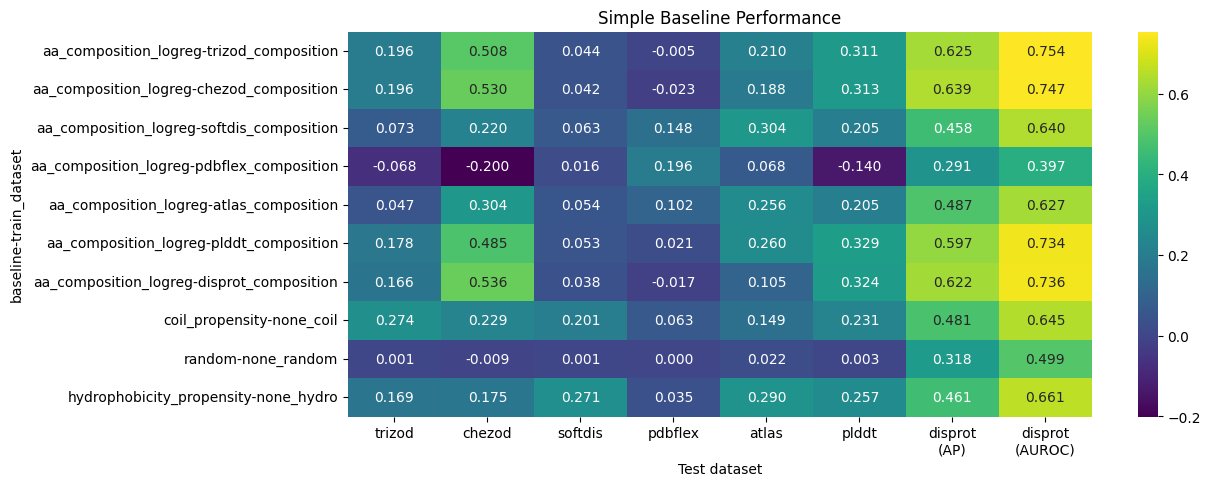

In [22]:
simple_plot = baseline_matrix.set_index(["baseline", "train_dataset"])[metric_cols]

plt.figure(figsize=(12, 5))
sns.heatmap(simple_plot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Test dataset")
plt.title("Simple Baseline Performance")
plt.show()


### 4. UdonPred Matrix As Headroom Above Baseline

The baseline models estimate how much performance can be explained by simple sequence signals, such as global amino-acid composition or local coil/hydrophobicity propensities. The headroom analysis asks how much performance remains after accounting for those simple signals.

For each test metric, we compute:

```text
headroom = UdonPred score - baseline score
```

Positive values mean that UdonPred adds predictive signal beyond the baseline. Values around zero mean that the simple baseline already explains most of the measured performance for that dataset/metric. Negative values mean that the selected baseline outperforms that UdonPred setting.

We use two views:

- `matched composition baseline`: compares each UdonPred training row to the amino-acid-composition baseline trained on the same dataset. This keeps the original 7x7 matrix structure.
- `best simple baseline`: compares UdonPred to the strongest available simple baseline for each test metric. This is the stricter and more conservative summary.


In [23]:
# Convert both result tables to numeric matrices with matching columns.
udon_scores = udon_matrix.set_index("train_dataset")[metric_cols].apply(pd.to_numeric)
baseline_scores = baseline_matrix.set_index(["baseline", "train_dataset"])[metric_cols].apply(pd.to_numeric)

headroom_dir = RESULTS / "headroom_above_baseline"
headroom_dir.mkdir(parents=True, exist_ok=True)

print("UdonPred matrix shape:", udon_scores.shape)
print("Baseline matrix shape:", baseline_scores.shape)


UdonPred matrix shape: (7, 8)
Baseline matrix shape: (10, 8)


#### 4.1 Headroom Against The Matched Composition Baseline

The amino-acid-composition baseline is trained once for each UdonPred training dataset. Therefore, it can be aligned row-by-row with the UdonPred matrix: `trizod` UdonPred is compared with `trizod_composition`, `chezod` UdonPred with `chezod_composition`, and so on.


In [24]:
matched_rows = {}
missing_rows = []
for train_dataset in udon_scores.index:
    key = ("aa_composition_logreg", f"{train_dataset}_composition")
    if key in baseline_scores.index:
        matched_rows[train_dataset] = baseline_scores.loc[key]
    else:
        missing_rows.append(key)

matched_composition_baseline = pd.DataFrame.from_dict(matched_rows, orient="index").reindex(udon_scores.index)
headroom_vs_matched_composition = udon_scores - matched_composition_baseline

if missing_rows:
    print("Missing matched composition baseline rows:", missing_rows)

headroom_vs_matched_composition.to_csv(headroom_dir / "headroom_vs_matched_composition.csv")
display(headroom_vs_matched_composition.style.format("{:.3f}"))


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
train_dataset,,,,,,,,
trizod,0.312,0.200,0.213,-0.001,0.203,0.408,0.273,0.176
chezod,0.290,0.161,0.193,-0.016,0.138,0.400,0.250,0.178
softdis,0.397,0.316,0.437,0.001,0.292,0.580,0.414,0.278
pdbflex,0.355,0.486,0.275,0.199,0.282,0.660,0.228,0.341
atlas,0.353,0.291,0.256,-0.047,0.452,0.514,0.383,0.293
plddt,0.245,0.140,0.231,0.083,0.252,0.510,0.278,0.193
disprot,0.198,0.127,0.217,0.116,0.519,0.450,0.313,0.223


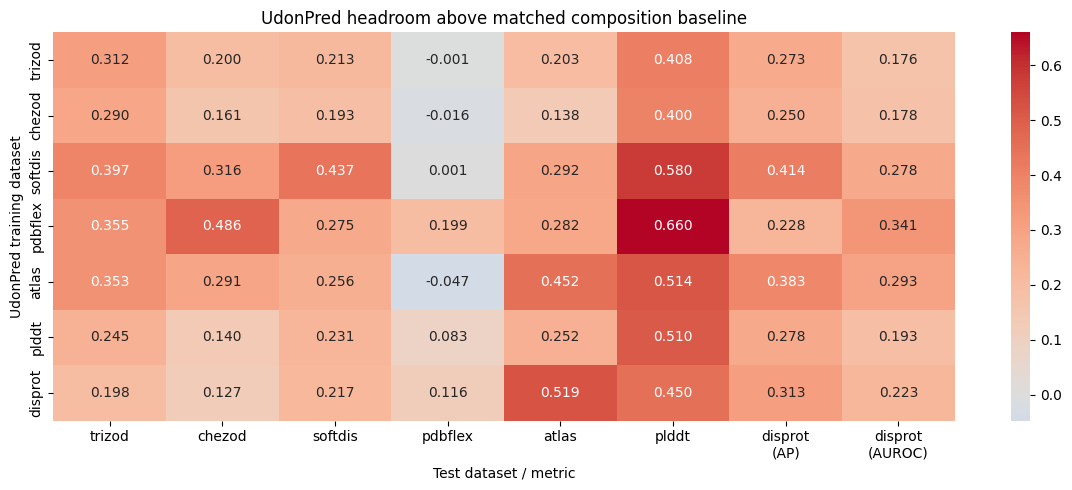

In [25]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    headroom_vs_matched_composition,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
)
plt.xlabel("Test dataset / metric")
plt.ylabel("UdonPred training dataset")
plt.title("UdonPred headroom above matched composition baseline")
plt.tight_layout()
plt.savefig(headroom_dir / "headroom_vs_matched_composition_heatmap.png", dpi=200)
plt.show()


#### 4.2 Headroom Against The Best Simple Baseline

The matched-composition view keeps the 7x7 structure, but it is not always the strongest baseline. For the final interpretation, we also compare UdonPred against the best simple baseline available for each test metric. This gives a stricter estimate of how much performance UdonPred adds above simple sequence-derived signal.


In [26]:
best_baseline_scores = baseline_scores.max(axis=0)
best_baseline_rows = baseline_scores.idxmax(axis=0)

best_baseline_summary = pd.DataFrame({
    "best_baseline": [row[0] for row in best_baseline_rows],
    "best_baseline_train_dataset": [row[1] for row in best_baseline_rows],
    "best_baseline_score": best_baseline_scores,
})

best_baseline_summary.to_csv(headroom_dir / "best_baseline_per_metric.csv")
display(best_baseline_summary.style.format({"best_baseline_score": "{:.3f}"}))


,best_baseline,best_baseline_train_dataset,best_baseline_score
trizod,coil_propensity,none_coil,0.274
chezod,aa_composition_logreg,disprot_composition,0.536
softdis,hydrophobicity_propensity,none_hydro,0.271
pdbflex,aa_composition_logreg,pdbflex_composition,0.196
atlas,aa_composition_logreg,softdis_composition,0.304
plddt,aa_composition_logreg,plddt_composition,0.329
disprot (AP),aa_composition_logreg,chezod_composition,0.639
disprot (AUROC),aa_composition_logreg,trizod_composition,0.754


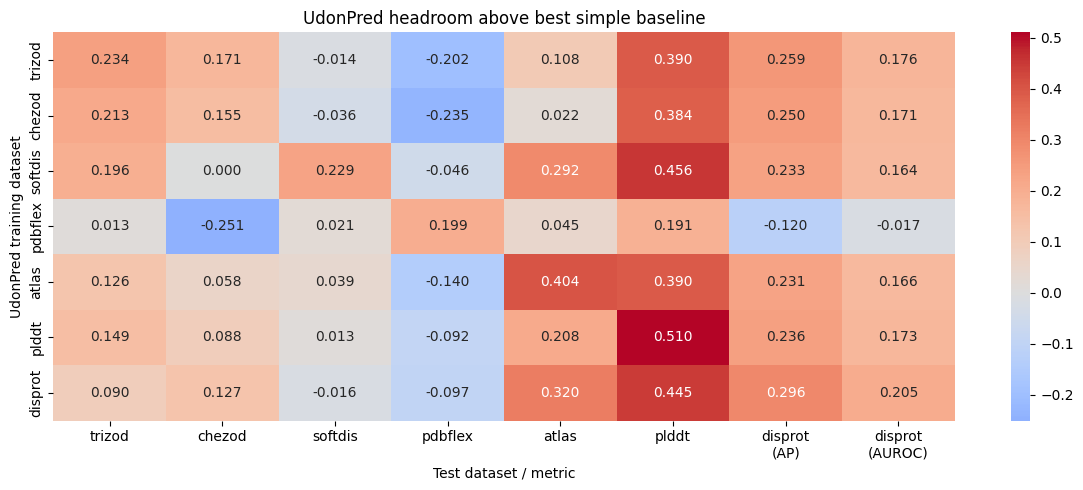

In [27]:
headroom_vs_best_baseline = udon_scores.subtract(best_baseline_scores, axis="columns")
headroom_vs_best_baseline.to_csv(headroom_dir / "headroom_vs_best_baseline.csv")

plt.figure(figsize=(12, 5))
sns.heatmap(
    headroom_vs_best_baseline,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
)
plt.xlabel("Test dataset / metric")
plt.ylabel("UdonPred training dataset")
plt.title("UdonPred headroom above best simple baseline")
plt.tight_layout()
plt.savefig(headroom_dir / "headroom_vs_best_baseline_heatmap.png", dpi=200)
plt.show()


#### 4.3 Compact Summary For The Report

The table below summarizes the most important comparison for each test metric: the best UdonPred score, the same-dataset UdonPred score, the best simple baseline score, and the remaining headroom.


In [28]:
best_udon_scores = udon_scores.max(axis=0)
best_udon_train = udon_scores.idxmax(axis=0)

same_dataset_scores = pd.Series({
    metric: udon_scores.loc[metric.split("\n")[0], metric]
    if metric.split("\n")[0] in udon_scores.index else np.nan
    for metric in metric_cols
})

headroom_summary = pd.DataFrame({
    "best_udon_training_dataset": best_udon_train,
    "best_udon_score": best_udon_scores,
    "same_dataset_udon_score": same_dataset_scores,
    "best_baseline": best_baseline_summary["best_baseline"],
    "best_baseline_train_dataset": best_baseline_summary["best_baseline_train_dataset"],
    "best_baseline_score": best_baseline_scores,
})
headroom_summary["headroom_best_udon_vs_best_baseline"] = (
    headroom_summary["best_udon_score"] - headroom_summary["best_baseline_score"]
)
headroom_summary["headroom_same_dataset_vs_best_baseline"] = (
    headroom_summary["same_dataset_udon_score"] - headroom_summary["best_baseline_score"]
)

headroom_summary.to_csv(headroom_dir / "headroom_summary.csv")
display(headroom_summary.style.format({
    "best_udon_score": "{:.3f}",
    "same_dataset_udon_score": "{:.3f}",
    "best_baseline_score": "{:.3f}",
    "headroom_best_udon_vs_best_baseline": "{:.3f}",
    "headroom_same_dataset_vs_best_baseline": "{:.3f}",
}))


,best_udon_training_dataset,best_udon_score,same_dataset_udon_score,best_baseline,best_baseline_train_dataset,best_baseline_score,headroom_best_udon_vs_best_baseline,headroom_same_dataset_vs_best_baseline
trizod,trizod,0.508,0.508,coil_propensity,none_coil,0.274,0.234,0.234
chezod,trizod,0.708,0.691,aa_composition_logreg,disprot_composition,0.536,0.171,0.155
softdis,softdis,0.500,0.500,hydrophobicity_propensity,none_hydro,0.271,0.229,0.229
pdbflex,pdbflex,0.395,0.395,aa_composition_logreg,pdbflex_composition,0.196,0.199,0.199
atlas,atlas,0.708,0.708,aa_composition_logreg,softdis_composition,0.304,0.404,0.404
plddt,plddt,0.839,0.839,aa_composition_logreg,plddt_composition,0.329,0.510,0.510
disprot (AP),disprot,0.935,0.935,aa_composition_logreg,chezod_composition,0.639,0.296,0.296
disprot (AUROC),disprot,0.959,0.959,aa_composition_logreg,trizod_composition,0.754,0.205,0.205


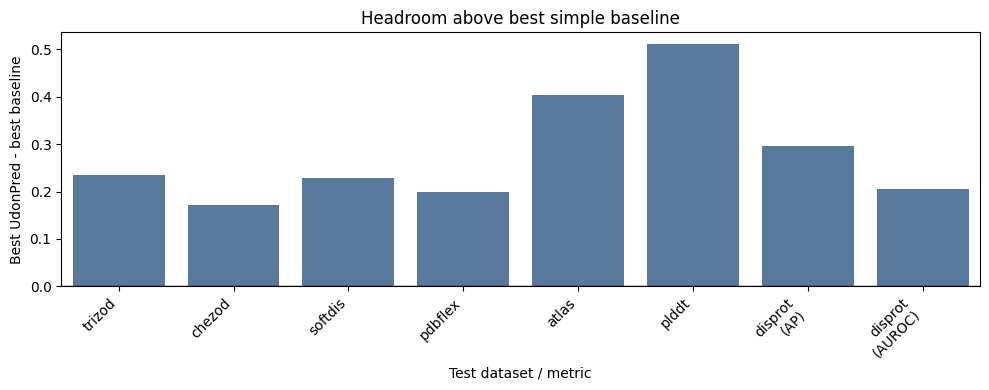

In [29]:
summary_plot = headroom_summary.reset_index(names="test_metric")

plt.figure(figsize=(10, 4))
sns.barplot(
    data=summary_plot,
    x="test_metric",
    y="headroom_best_udon_vs_best_baseline",
    color="#4C78A8",
)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Test dataset / metric")
plt.ylabel("Best UdonPred - best baseline")
plt.title("Headroom above best simple baseline")
plt.tight_layout()
plt.savefig(headroom_dir / "headroom_summary_barplot.png", dpi=200)
plt.show()


In [30]:
largest_headroom_metric = headroom_summary["headroom_best_udon_vs_best_baseline"].idxmax()
smallest_headroom_metric = headroom_summary["headroom_best_udon_vs_best_baseline"].idxmin()

print("Report notes:")
print(
    f"- Largest headroom: {largest_headroom_metric} "
    f"({headroom_summary.loc[largest_headroom_metric, 'headroom_best_udon_vs_best_baseline']:.3f})."
)
print(
    f"- Smallest headroom: {smallest_headroom_metric} "
    f"({headroom_summary.loc[smallest_headroom_metric, 'headroom_best_udon_vs_best_baseline']:.3f})."
)
print(
    f"- Mean headroom across metrics: "
    f"{headroom_summary['headroom_best_udon_vs_best_baseline'].mean():.3f}."
)


Report notes:
- Largest headroom: plddt (0.510).
- Smallest headroom: chezod (0.171).
- Mean headroom across metrics: 0.281.


### 5. Interpretation Draft

This section evaluates UdonPred as headroom above simple baselines rather than only reporting raw prediction performance. The matched-composition comparison preserves the original cross-dataset matrix and asks whether each UdonPred model improves over a baseline trained from the same dataset. The best-baseline comparison is stricter: for each test metric, UdonPred is compared against whichever simple baseline performed best.

The main quantity is `best UdonPred score - best baseline score`. Positive headroom indicates that UdonPred learns information beyond simple amino-acid composition, coil propensity, hydrophobicity, or random scoring. Small or negative headroom suggests that the corresponding benchmark is strongly explainable by simple sequence statistics, or that the tested UdonPred model does not transfer well to that annotation type.

The files written to `results/headroom_above_baseline/` are the reusable outputs for this task: the two headroom matrices, the per-metric best-baseline table, and the compact summary table for the report.


### 6. Normalized Headroom Against Annotation Ceiling

The raw baseline headroom above is useful, but it does not account for how much agreement the annotations themselves allow. Here we normalize the best-simple-baseline delta by the metric-matched annotation ceiling:

```text
(UdonPred - best simple baseline) / (annotation ceiling - best simple baseline)
```

Diagonal cells use a ceiling of `1.0`. Off-diagonal dataset pairs without exact annotation overlap remain `NaN`; cells where the ceiling is not above the baseline are also left blank and described in `cell_status.csv`.


In [31]:
import subprocess
import sys

normalized_dir = RESULTS / "normalized_headroom"
normalized_matrix_path = normalized_dir / "normalized_headroom_vs_best_simple_baseline.csv"
ceiling_summary_path = RESULTS / "annotation_ceiling" / "annotation_ceiling_summary.csv"

if not ceiling_summary_path.exists():
    print("Running annotation ceiling computation...")
    cmd = [
        sys.executable,
        str(ROOT / "scripts" / "estimate_annotation_ceiling.py"),
        "--udonpred-dir", str(ROOT / "UdonPred"),
        "--output-dir", str(RESULTS / "annotation_ceiling"),
    ]
    subprocess.run(cmd, cwd=ROOT, check=True)

if not normalized_matrix_path.exists():
    print("Running normalized headroom computation...")
    cmd = [sys.executable, str(ROOT / "scripts" / "compute_normalized_headroom.py")]
    subprocess.run(cmd, cwd=ROOT, check=True)
else:
    print("Normalized headroom outputs already exist, loading existing files.")

normalized_headroom = pd.read_csv(normalized_matrix_path, index_col=0)
ceiling_matrix = pd.read_csv(normalized_dir / "ceiling_matrix.csv", index_col=0)
available_headroom = pd.read_csv(normalized_dir / "available_headroom_vs_best_simple_baseline.csv", index_col=0)
cell_status = pd.read_csv(normalized_dir / "cell_status.csv")
normalized_summary = pd.read_csv(normalized_dir / "normalized_headroom_summary.csv")

display(normalized_headroom.style.format("{:.3f}"))


Normalized headroom outputs already exist, loading existing files.


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
trizod,0.322,nan,-0.066,nan,nan,2.217,nan,nan
chezod,1.020,0.334,-0.586,nan,nan,1.061,nan,nan
softdis,0.947,nan,0.314,nan,27.180,1.389,nan,0.930
pdbflex,nan,nan,nan,0.248,nan,nan,nan,nan
atlas,nan,nan,0.881,nan,0.580,nan,nan,nan
plddt,0.645,0.570,0.033,nan,nan,0.760,nan,nan
disprot,nan,nan,-0.074,nan,nan,nan,0.820,0.832


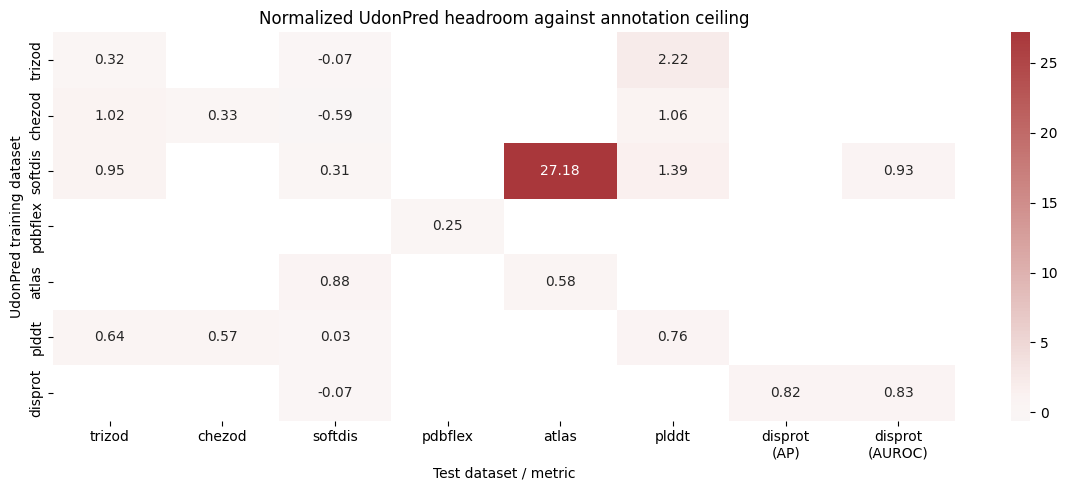

Cell status counts:


,n
status,
ok,22
ceiling_not_above_baseline,18
missing_ceiling,16


,test_metric,best_udon_training_dataset,best_udon_score,same_dataset_udon_score,best_simple_baseline,best_simple_baseline_train_dataset,best_simple_baseline_score,best_udon_annotation_ceiling,best_udon_available_headroom,best_udon_raw_headroom,best_udon_normalized_headroom,best_udon_status,same_dataset_annotation_ceiling,same_dataset_available_headroom,same_dataset_raw_headroom,same_dataset_normalized_headroom,same_dataset_status,best_normalized_training_dataset,best_normalized_headroom
0,trizod,trizod,0.507853,0.507853,coil_propensity,none_coil,0.273706,1.000000,0.726294,0.234147,0.322386,ok,1.0,0.726294,0.234147,0.322386,ok,chezod,1.020478
1,chezod,trizod,0.707732,0.691124,aa_composition_logreg,disprot_composition,0.536459,0.481978,-0.054481,0.171273,NaN,ceiling_not_above_baseline,1.0,0.463541,0.154665,0.333660,ok,plddt,0.570110
2,softdis,softdis,0.499879,0.499879,hydrophobicity_propensity,none_hydro,0.270916,1.000000,0.729084,0.228963,0.314042,ok,1.0,0.729084,0.228963,0.314042,ok,atlas,0.881170
3,pdbflex,pdbflex,0.395383,0.395383,aa_composition_logreg,pdbflex_composition,0.196044,1.000000,0.803956,0.199339,0.247948,ok,1.0,0.803956,0.199339,0.247948,ok,pdbflex,0.247948
4,atlas,atlas,0.708063,0.708063,aa_composition_logreg,softdis_composition,0.304284,1.000000,0.695716,0.403779,0.580379,ok,1.0,0.695716,0.403779,0.580379,ok,softdis,27.180398
5,plddt,plddt,0.838924,0.838924,aa_composition_logreg,plddt_composition,0.328734,1.000000,0.671266,0.510190,0.760041,ok,1.0,0.671266,0.510190,0.760041,ok,trizod,2.217450
6,disprot\n(AP),disprot,0.935162,0.935162,aa_composition_logreg,chezod_composition,0.639465,1.000000,0.360535,0.295697,0.820162,ok,1.0,0.360535,0.295697,0.820162,ok,disprot,0.820162
7,disprot\n(AUROC),disprot,0.958705,0.958705,aa_composition_logreg,trizod_composition,0.753995,1.000000,0.246005,0.204710,0.832138,ok,1.0,0.246005,0.204710,0.832138,ok,softdis,0.929738


In [32]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    normalized_headroom,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    mask=normalized_headroom.isna(),
)
plt.xlabel("Test dataset / metric")
plt.ylabel("UdonPred training dataset")
plt.title("Normalized UdonPred headroom against annotation ceiling")
plt.tight_layout()
plt.savefig(normalized_dir / "normalized_headroom_vs_best_simple_baseline_heatmap.png", dpi=200)
plt.show()

print("Cell status counts:")
display(cell_status["status"].value_counts().to_frame("n"))
display(normalized_summary)


### 7. Shuffled-Label Null

The shuffled-label workflow estimates an empirical null for UdonPred heads trained on randomized residue labels. The current repository has one completed seed, so these numbers are exploratory and should not be treated as stable uncertainty intervals.


In [33]:
shuffled_summary = pd.read_csv(normalized_dir / "shuffled_null_summary.csv")
shuffled_mean = pd.read_csv(normalized_dir / "shuffled_null_mean_matrix.csv", index_col=0)
udon_minus_shuffled = pd.read_csv(normalized_dir / "udon_minus_shuffled_null.csv", index_col=0)
normalized_vs_shuffled = pd.read_csv(normalized_dir / "normalized_headroom_vs_shuffled_null.csv", index_col=0)

if shuffled_summary["n"].max() == 1:
    print("Only one shuffled-label seed is available; interpret this null comparison as exploratory.")

display(shuffled_summary)
display(udon_minus_shuffled.style.format("{:.3f}"))


Only one shuffled-label seed is available; interpret this null comparison as exploratory.


,train_dataset,test_metric,n,mean,std,q025,q500,q975,is_exploratory
0,atlas,atlas,1,-0.204216,NaN,-0.204216,-0.204216,-0.204216,True
1,atlas,chezod,1,-0.445006,NaN,-0.445006,-0.445006,-0.445006,True
2,atlas,disprot\n(AP),1,0.197480,NaN,0.197480,0.197480,0.197480,True
3,atlas,disprot\n(AUROC),1,0.169990,NaN,0.169990,0.169990,0.169990,True
4,atlas,pdbflex,1,0.114774,NaN,0.114774,0.114774,0.114774,True
5,atlas,plddt,1,-0.456655,NaN,-0.456655,-0.456655,-0.456655,True
6,atlas,softdis,1,0.074813,NaN,0.074813,0.074813,0.074813,True
7,atlas,trizod,1,-0.126227,NaN,-0.126227,-0.126227,-0.126227,True
8,chezod,atlas,1,-0.410959,NaN,-0.410959,-0.410959,-0.410959,True
9,chezod,chezod,1,-0.207731,NaN,-0.207731,-0.207731,-0.207731,True


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
train_dataset,,,,,,,,
trizod,0.623,0.611,0.510,0.125,0.771,0.668,0.516,0.348
chezod,0.783,0.899,0.568,0.053,0.738,1.075,0.662,0.617
softdis,0.332,0.013,0.583,0.146,0.386,0.263,0.243,0.096
pdbflex,0.127,-0.208,0.360,0.425,0.115,-0.013,-0.068,-0.068
atlas,0.526,1.040,0.235,-0.059,0.912,1.175,0.673,0.750
plddt,0.640,0.893,0.523,0.053,0.665,1.338,0.674,0.746
disprot,0.406,0.764,0.245,0.031,0.633,0.848,0.636,0.472


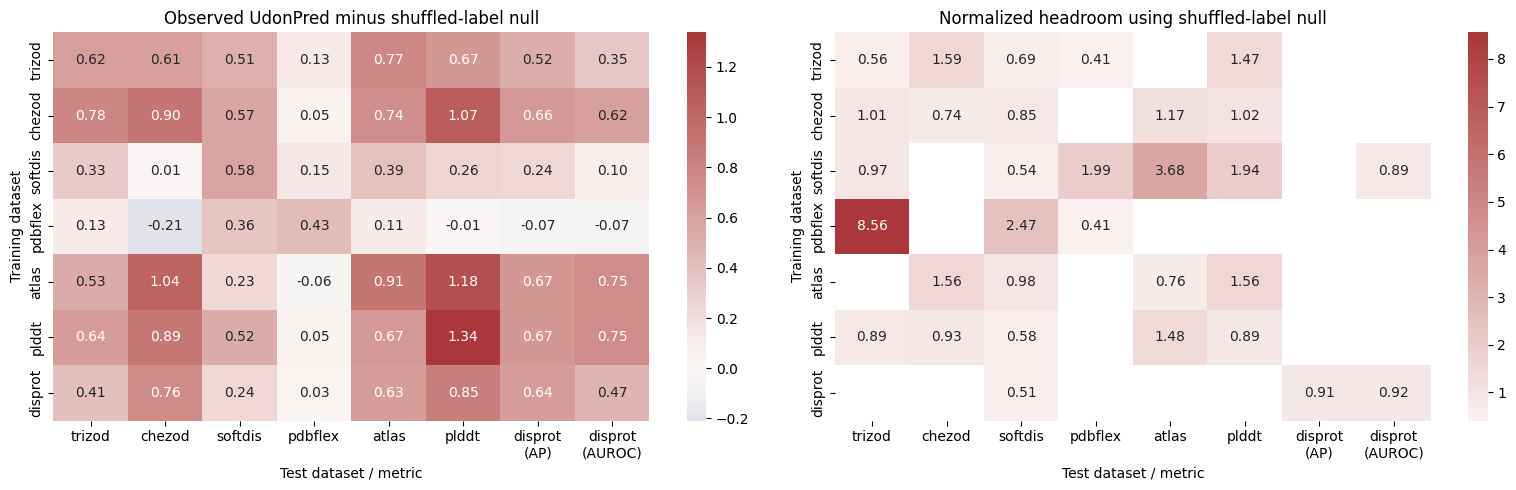

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(
    udon_minus_shuffled,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    ax=axes[0],
)
axes[0].set_title("Observed UdonPred minus shuffled-label null")
axes[0].set_xlabel("Test dataset / metric")
axes[0].set_ylabel("Training dataset")

sns.heatmap(
    normalized_vs_shuffled,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    mask=normalized_vs_shuffled.isna(),
    ax=axes[1],
)
axes[1].set_title("Normalized headroom using shuffled-label null")
axes[1].set_xlabel("Test dataset / metric")
axes[1].set_ylabel("Training dataset")

plt.tight_layout()
plt.savefig(normalized_dir / "shuffled_null_headroom_heatmaps.png", dpi=200)
plt.show()
